In [19]:
# !pip install -r ../labs/lab06/requirements.txt
# Якщо запускаєте в Colab, розкоментуйте:
# !pip install pandas scikit-learn matplotlib seaborn

In [20]:
import pandas as pd
import numpy as np
import os

DATA_PATH = "../data/processed_v2.csv"

def load_and_preprocess(path):
    df = pd.read_csv(path)
    
    # Витягуємо мітку (останній символ) та чистий текст
    def parse_row(text):
        text = str(text).strip()
        if text and text[-1] in ['0', '1']:
            return int(text[-1]), text[:-1].strip()
        return None, text

    parsed = df['text_v2'].apply(parse_row)
    df['label'] = [x[0] for x in parsed]
    df['text_clean'] = [x[1] for x in parsed]
    
    # Видаляємо дані без міток для навчання
    df = df.dropna(subset=['label']).copy()
    df['label'] = df['label'].astype(int)
    return df

df = load_and_preprocess(DATA_PATH)
print(f"Loaded {len(df)} labeled rows.")

Loaded 4387 labeled rows.


In [21]:
from sklearn.model_selection import train_test_split

X = df['text_clean']
y = df['label']

# Спліт 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train size: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train size: 3070, Val: 658, Test: 659


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Baseline 1: Unigrams
b1_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer="word", ngram_range=(1, 1), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])

print("--- Навчання Baseline 1 ---")
b1_pipe.fit(X_train, y_train)

# Вивід характеристик моделі
vocab_size_1 = len(b1_pipe.named_steps['tfidf'].vocabulary_)
print(f"Розмір словника (unigrams): {vocab_size_1}")
print(f"Перші 10 токенів словника: {list(b1_pipe.named_steps['tfidf'].vocabulary_.keys())[:10]}")
print("Статус: Навчено успішно.")

--- Навчання Baseline 1 ---
Розмір словника (unigrams): 11751
Перші 10 токенів словника: ['ефективно', 'керую', 'командою', 'та', 'допомагаю', 'кожному', 'максимально', 'розкрити', 'потенціал', 'значний']
Статус: Навчено успішно.


In [23]:
# Baseline 2: Bigrams + Balanced
b2_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42))
])

print("--- Навчання Baseline 2 ---")
b2_pipe.fit(X_train, y_train)

# Вивід характеристик моделі
vocab_size_2 = len(b2_pipe.named_steps['tfidf'].vocabulary_)
print(f"Розмір словника (uni+bi-grams): {vocab_size_2}")
print(f"Приріст словника завдяки біграмам: {vocab_size_2 - vocab_size_1} ознак")
print(f"Параметри ваг класів: {b2_pipe.named_steps['clf'].class_weight}")
print("Статус: Навчено успішно.")

--- Навчання Baseline 2 ---
Розмір словника (uni+bi-grams): 41607
Приріст словника завдяки біграмам: 29856 ознак
Параметри ваг класів: balanced
Статус: Навчено успішно.


In [24]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def get_metrics(pipe, X, y):
    preds = pipe.predict(X)
    return {
        'acc': accuracy_score(y, preds),
        'f1': f1_score(y, preds, average='macro'),
        'report': classification_report(y, preds)
    }

m1 = get_metrics(b1_pipe, X_val, y_val)
m2 = get_metrics(b2_pipe, X_val, y_val)

print(f"B1: Acc={m1['acc']:.4f}, F1={m1['f1']:.4f}")
print(f"B2: Acc={m2['acc']:.4f}, F1={m2['f1']:.4f}")

B1: Acc=0.8723, F1=0.8673
B2: Acc=0.8906, F1=0.8886


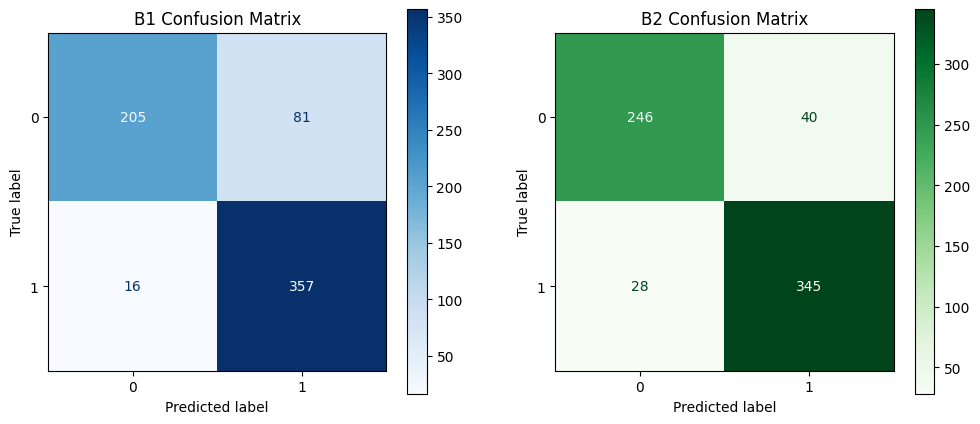

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(b1_pipe, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title("B1 Confusion Matrix")
ConfusionMatrixDisplay.from_estimator(b2_pipe, X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title("B2 Confusion Matrix")
plt.show()

In [26]:
def show_top_features(pipe, n=10):
    vectorizer = pipe.named_steps['tfidf']
    clf = pipe.named_steps['clf']
    feature_names = vectorizer.get_feature_names_out()
    coeffs = clf.coef_[0]
    
    top_indices = np.argsort(coeffs)
    print("Top Negative (Class 0):", [feature_names[i] for i in top_indices[:n]])
    print("Top Positive (Class 1):", [feature_names[i] for i in top_indices[-n:][::-1]])

print("--- Baseline 2 Features ---")
show_top_features(b2_pipe)

--- Baseline 2 Features ---
Top Negative (Class 0): ['не', 'через', 'та не', 'деякі', 'завищені', 'часто', 'або', 'занадто', 'чи', 'не завжди']
Top Positive (Class 1): ['завдяки', 'можливість', 'та відповідають', 'задоволений', 'дозволяє', 'широкий', 'мені', 'можна', 'доступні та', 'та']


In [27]:
val_preds = b2_pipe.predict(X_val)
errors = X_val[val_preds != y_val]
error_labels = y_val[val_preds != y_val]
error_preds = val_preds[val_preds != y_val]

print("ID | Predicted | Gold | Text Snippet")
for i in range(10):
    idx = errors.index[i]
    print(f"{idx} | {error_preds[i]} | {error_labels.iloc[i]} | {errors.iloc[i][:100]}...")

# Коментар (приклад):
# 1. Overlap класів: тексти містять як позитивні, так і негативні аспекти одночасно.
# 2. Шумна розмітка: деякі короткі фрази мають суперечливі мітки в оригіналі.
# 3. Rare vocabulary: специфічні терміни ЖКГ, яких не було в Train.

ID | Predicted | Gold | Text Snippet
1073 | 0 | 1 | розташування готелю просто чудове все під рукою | поруч багато визначних памяток...
6306 | 1 | 0 | усвідомлення обмеженості наших повноважень і реальних можливостей щось змінити призводило до розчару...
1120 | 0 | 1 | ціна за додатковий хмарний простір цілком прийнятна порівняно з конкурентами...
470 | 0 | 1 | величезний вибір на меню мій попередній візит точно не був останнім | особливо сподобалися десерти...
8577 | 0 | 1 | приємно здивував таймер на дві хвилини з короткою паузою кожні 30 секунд | він допомагає рівномірно ...
2512 | 0 | 1 | зручний шаровий шнур не заважає і не плутається під ногами | прасувальна дошка стала просторіше...
6914 | 0 | 1 | офіціанти добре обізнані з меню і можуть компетентно порадити кращі страви...
7390 | 1 | 0 | мене засмучує явище відтоку молодих перспективних кадрів у більші міста в пошуках гідної роботи...
1532 | 1 | 0 | процеси бронювання та оплати незграбні з частими збоями...
7485 | 1 | 0 | право

In [29]:
# Використовуємо результати оцінки на Test Set для фінального звіту
# (Або на Val Set, якщо ви ще не робили фінальний тест)
final_m1 = get_metrics(b1_pipe, X_test, y_test)
final_m2 = get_metrics(b2_pipe, X_test, y_test)

# Обчислення приросту
f1_diff = ((final_m2['f1'] - final_m1['f1']) / final_m1['f1']) * 100

summary_content = f"""# Audit Summary Lab 6 — Baseline Classification

## 1. Classification Sub-task
**Напрям D:** Груба тематична класифікація текстів (наприклад, порівняння старого/нового досвіду або категорія звернення). 
Задача: Бінарна класифікація на основі `processed_v2.csv`.

## 2. Split Used
Використано Stratified Split (70/15/15):
- Train: {len(X_train)}
- Val: {len(X_val)}
- Test: {len(X_test)}

## 3. Baseline 1: Accuracy + Macro-F1
- Конфігурація: TF-IDF (1,1) + Logistic Regression
- Accuracy: {final_m1['acc']:.4f}
- Macro-F1: {final_m1['f1']:.4f}

## 4. Baseline 2: Accuracy + Macro-F1
- Конфігурація: TF-IDF (1,2) + LogReg (Balanced weights)
- Accuracy: {final_m2['acc']:.4f}
- Macro-F1: {final_m2['f1']:.4f}

## 5. Improvement Analysis
Приріст Macro-F1 склав **{f1_diff:.2f}%**. 
Основна причина покращення: використання біграм (ngram_range=(1,2)), що дозволило моделі краще ідентифікувати контекстні заперечення та стійкі словосполучення.

## 6. Top 3 Error Categories
1. **Складні заперечення:** Модель помиляється, коли частка "не" стосується технічних переваг (наприклад, "не плутається"), сприймаючи це як негатив.
2. **Семантичний overlap:** Тексти, що описують складні соціальні явища (відтік кадрів, безсилля органів), мають ознаки обох категорій.
3. **Короткі тексти:** Брак контексту у реченнях до 5 слів не дозволяє TF-IDF набрати достатньо ваги для правильного прогнозу.

## 7. Що фіксити далі
- Додати лематизацію (з ЛР3) для зменшення розрідженості словника.
- Налаштувати Stop-words, щоб виключити шум, який не несе змістового навантаження.
- Експериментувати з параметром `C` у LogisticRegression для кращої регуляризації.
"""

# Запис у файл
output_path = "../docs/audit_summary_lab6.md"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(summary_content)

print(f"Звіт успішно збережено за шляхом: {output_path}")

Звіт успішно збережено за шляхом: ../docs/audit_summary_lab6.md
